In [1]:
# -*- coding: utf-8 -*-
"""
================================================================================
 원피스 "이무 = 앵무새론" EDA 분석 스크립트
================================================================================
 목적:
   r/OnePiece 게시글 데이터를 이용해, 2026-07-15경 한국 커뮤니티에서 제기된
   "이무(Imu)의 정체는 앵무새(parrot)"라는 가설이 레딧에서 어떻게 확산됐는지 분석한다.

 분석 흐름:
   1. 두 CSV 병합 → 2. 중복 제거 → 3. datetime 변환 → 4. dtype 확인
   5. 앵무새론 게시글 분류 → 6. 일자별 집계 → 7. before/after 비교 → 8. 시각화

 분류 규칙 (사전 검증 완료, 정밀도 ~100%):
   앵무새론 = 제목에 'parrot' 포함  OR  ('imu' 그리고 'bird' 동시 포함)
   점유율 분모 = 전체 원피스 게시글  (②번 방식)

 주의(한계):
   데이터에 '본문'이 없고 '제목'만 있으므로, 제목에 키워드가 없는 앵무새론 글은
   놓친다. 따라서 아래 수치는 '실제 규모의 하한선'이며, 절대량보다 '추세'를 신뢰한다.
================================================================================

"""
from matplotlib import font_manager
for f in font_manager.fontManager.ttflist:
    name = f.name
    if any(k in name for k in ['Gothic', 'Malgun', 'Nanum', 'Batang', 'Gulim', 'Dotum']):
        print(name)


Franklin Gothic Medium
NanumBarunGothic
Gulim
GulimChe
Dotum
DotumChe
HCR Dotum
HCR Batang
NanumSquareOTF
NanumSquareOTF Bold
NanumBarunGothic
NanumBarunGothic UltraLight
NanumGothicOTF
NanumGothicOTFLight
Century Gothic
NanumSquare Neo
NanumSquare Neo Light
NanumGothicOTF
NanumSquare
NanumSquare ExtraBold
NanumGothic
NanumGothicExtraBold
Malgun Gothic
New Gulim
Han Santteut Dotum
NanumGothic
NanumSquare Neo OTF
NanumSquare Neo OTF Heavy
HCR Batang Ext
KoPubWorldBatang_Pro
KoPubWorldBatang_Pro Light
NanumGothicOTF
NanumGothicOTFExtraBold
Hancom Gothic
Jalnan Gothic
Franklin Gothic Heavy
Yu Gothic
Yu Gothic UI
Yu Gothic UI Semilight
NanumSquareOTF_ac
NanumSquareOTF_ac Light
Hancom Gothic
Batang
BatangChe
Yu Gothic
Yu Gothic Medium
Yu Gothic UI
Copperplate Gothic Light
NanumSquare_ac
NanumSquare_ac Bold
Century Gothic
HCR Dotum Ext
Showcard Gothic
NanumSquareOTF_ac
NanumSquareOTF_ac ExtraBold
KoPubWorldBatang_Pro
KoPubWorldBatang_Pro Bold
Franklin Gothic Demi
NanumGothic
Century Gothic
N

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 0. 라이브러리 import
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd                     # 데이터 처리 (표 형태 다루기)
import numpy as np                      # 수치 연산 (보조)
import matplotlib.pyplot as plt         # 시각화 기본 엔진
import matplotlib.dates as mdates       # 날짜 축 눈금 포맷팅용
import seaborn as sns                   # 시각화 스타일/보조
import platform
import matplotlib.pyplot as plt

sns.set_style('whitegrid')              # seaborn 격자 스타일 적용

plt.rcParams['font.family'] = 'NanumGothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)

CUTOFF = pd.Timestamp('2026-07-15', tz='Asia/Seoul')  # 가설 제기일 (KST 기준선)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. 데이터 불러오기 & 병합(concat)
# ─────────────────────────────────────────────────────────────────────────────
# 두 파일은 수집 기간만 다르고 컬럼 구조가 같다(9일치 ⊂ 16일치).
# 세로로 이어붙이는 concat을 쓴다. (좌우로 붙이는 merge/join이 아님에 주의)
df_9  = pd.read_csv('reddit_onepiece_9days.csv')
df_16 = pd.read_csv('reddit_onepiece_16days.csv')
print(f'[1] 불러오기 — 9일치 {len(df_9)}행 / 16일치 {len(df_16)}행')

# axis=0(기본): 행 방향으로 쌓기. ignore_index로 인덱스 새로 매김.
df = pd.concat([df_9, df_16], axis=0, ignore_index=True)
print(f'[1] 병합 직후(중복 포함): {len(df)}행')


[1] 불러오기 — 9일치 999행 / 16일치 2431행
[1] 병합 직후(중복 포함): 3430행


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. 중복 제거 (dedup)
# ─────────────────────────────────────────────────────────────────────────────
# '링크'는 게시글마다 고유한 ID를 포함하므로 중복 제거의 '열쇠'로 가장 안전하다.
# (제목은 우연히 같을 수 있으나, 링크는 게시글당 유일하다.)
before = len(df)
df = df.drop_duplicates(subset='링크').reset_index(drop=True)
print(f'[2] 중복 제거: {before}행 → {len(df)}행 (제거 {before - len(df)}건)')


[2] 중복 제거: 3430행 → 2431행 (제거 999건)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. datetime 변환 + 시간대(UTC → KST) 처리
# ─────────────────────────────────────────────────────────────────────────────
# 원본 '작성시간(UTC)'은 문자열(str)이라 날짜 계산이 불가능하다. datetime으로 바꾼다.
# 또한 이 가설은 '한국' 커뮤니티에서 7/15에 나온 것이므로, 날짜 기준을
# 한국 시간(KST=UTC+9)으로 맞춰야 '7월 15일'의 경계가 정확해진다.
df['작성시간'] = pd.to_datetime(df['작성시간(UTC)'])          # 문자열 → datetime
df['작성시간'] = df['작성시간'].dt.tz_localize('UTC')          # 이 값이 UTC임을 명시
df['작성시간_KST'] = df['작성시간'].dt.tz_convert('Asia/Seoul')  # 한국 시간으로 변환

# .dt.normalize(): 시:분:초를 0으로 만들어 '그 날의 자정' datetime으로 통일 → 일자별 집계 키
df['날짜'] = df['작성시간_KST'].dt.normalize()
print(f'[3] 기간(KST): {df["날짜"].min().date()} ~ {df["날짜"].max().date()}')

[3] 기간(KST): 2026-07-08 ~ 2026-07-24


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. 데이터 타입 확인 (교안대로 dtype 점검)
# ─────────────────────────────────────────────────────────────────────────────
# 전처리 후 각 컬럼이 의도한 타입인지 확인하는 습관. '작성시간'이 datetime64인지,
# '공감수/댓글수'가 정수인지 확인한다. 여기서 어긋나면 이후 계산이 틀어진다.
print('\n[4] dtype 확인')
print(df.dtypes)
print('\n[4] 결측치 확인')
print(df.isna().sum())


[4] dtype 확인
작성시간(UTC)                           str
제목                                  str
공감수                               int64
댓글수                               int64
작성자                                 str
링크                                  str
작성시간                datetime64[us, UTC]
작성시간_KST     datetime64[us, Asia/Seoul]
날짜           datetime64[us, Asia/Seoul]
dtype: object

[4] 결측치 확인
작성시간(UTC)    0
제목           0
공감수          0
댓글수          0
작성자          0
링크           0
작성시간         0
작성시간_KST     0
날짜           0
dtype: int64


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. 앵무새론 게시글 분류
# ─────────────────────────────────────────────────────────────────────────────
# 규칙: 제목에 'parrot' 포함  OR  ('imu'와 'bird' 동시 포함)
#   - parrot : 원피스 맥락에서 거의 안 쓰이는 단어 → 등장 시 앵무새론일 확률 매우 높음(검증됨)
#   - imu+bird : parrot 없이 'bird'로 우회 표현한 글(예: "IMU bird theory")까지 포착
# str.contains는 정규표현식 기반. case=False로 대소문자 무시, na=False로 결측 안전 처리.
title = df['제목'].str.lower()          # 소문자 통일(대소문자 섞임 방지)
has_parrot = title.str.contains('parrot', case=False, na=False)
has_imu    = title.str.contains('imu',    case=False, na=False)
has_bird   = title.str.contains('bird',   case=False, na=False)

df['앵무새론'] = has_parrot | (has_imu & has_bird)   # 분자: 앵무새론 여부
df['이무언급'] = has_imu                             # 참고: 일반 이무 논의량

n_parrot = int(df['앵무새론'].sum())
print(f'\n[5] 전체 {len(df)}건 중 → 이무 언급 {int(df["이무언급"].sum())}건, '
      f'앵무새론 {n_parrot}건 (전체 대비 {n_parrot/len(df):.2%})')

# (검증) 앵무새론으로 분류된 제목을 눈으로 확인 — 오탐 점검용
print('\n[5] 앵무새론으로 분류된 제목:')
for t in df.loc[df['앵무새론'], '제목'].tolist():
    print('    •', t)


[5] 전체 2431건 중 → 이무 언급 91건, 앵무새론 21건 (전체 대비 0.86%)

[5] 앵무새론으로 분류된 제목:
    • My opinion on the imu parrot theory
    • Imu is a parrot theory and the will of D's
    • “IMU” bird theory
    • SPOILERS: Imu parrot theory and Blackbeard being the final villian
    • I think I actually just connected the "Imu is a Parrot" theory to Mihawk...
    • What are your thoughts on imu parrot theory?
    • Noticed a mind-blowing foreshadowing in Skypiea regarding the Imu = Parrot theory
    • Is Imu actually a parrot?
    • Add on to Imu parrot theory
    • Add on to the imu parrot theory
    • Parroting the Parrot Theory
    • I just had a completely ridiculous theory, but hear me out: Imu is actually a parrot.
    • To parrot theory supporters, from one Korean
    • Imu = Parrot Theory Additional Evidence Part 3. Wait, I swear I see feathers on Imu.
    • Imu = Parrot Theory Additional Evidence Part 2
    • Ultimate Parrot Theory
    • Is Imu Actually a Parrot? The Wild One Piece Theory That To

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. 일자별 집계 (시계열 준비)
# ─────────────────────────────────────────────────────────────────────────────
# 날짜별로 (전체 게시글 수, 앵무새론 수, 이무언급 수)를 집계한다.
daily = df.groupby('날짜').agg(
    전체=('제목', 'size'),          # 그날의 전체 게시글 수
    앵무새론=('앵무새론', 'sum'),    # 그날의 앵무새론 수 (True=1 합)
    이무언급=('이무언급', 'sum'),    # 그날의 이무 언급 수
).reset_index()

# 점유율(분모②): 전체 게시글 중 앵무새론 비율 (%)
daily['점유율'] = daily['앵무새론'] / daily['전체'] * 100

print('\n[6] 일자별 집계')
print(daily.to_string(index=False))


[6] 일자별 집계
                       날짜  전체  앵무새론  이무언급      점유율
2026-07-08 00:00:00+09:00  97     0     2 0.000000
2026-07-09 00:00:00+09:00 186     0     7 0.000000
2026-07-10 00:00:00+09:00 181     0     6 0.000000
2026-07-11 00:00:00+09:00 202     0     7 0.000000
2026-07-12 00:00:00+09:00 168     0     8 0.000000
2026-07-13 00:00:00+09:00 222     0     5 0.000000
2026-07-14 00:00:00+09:00 195     0     7 0.000000
2026-07-15 00:00:00+09:00 194     0     4 0.000000
2026-07-16 00:00:00+09:00 110     2     6 1.818182
2026-07-17 00:00:00+09:00 112     3     7 2.678571
2026-07-18 00:00:00+09:00 125     4     5 3.200000
2026-07-19 00:00:00+09:00  99     0     2 0.000000
2026-07-20 00:00:00+09:00 113     0     1 0.000000
2026-07-21 00:00:00+09:00 116     1     4 0.862069
2026-07-22 00:00:00+09:00 119     3     8 2.521008
2026-07-23 00:00:00+09:00 122     4     6 3.278689
2026-07-24 00:00:00+09:00  70     4     6 5.714286


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. before / after 비교 (7/15 기준)  ── "확정 기준 A: 불연속성"
# ─────────────────────────────────────────────────────────────────────────────
# 가설 제기일(7/15)을 경계로 앵무새론이 이전엔 거의 없다가 이후 급증하는지 본다.
before_mask = df['날짜'] <  CUTOFF
after_mask  = df['날짜'] >= CUTOFF
b_parrot = int(df.loc[before_mask, '앵무새론'].sum())
a_parrot = int(df.loc[after_mask,  '앵무새론'].sum())
verdict = '확정 (불연속적 급증 관측)' if (b_parrot == 0 and a_parrot > 0) else '추가 검토 필요'

print('\n[7] === 확정 기준 A : 7/15 전후 비교 ===')
print(f'    앵무새론 건수  : 이전 {b_parrot} → 이후 {a_parrot}')
print(f'    전체 대비 점유 : 이전 {b_parrot/max(before_mask.sum(),1):.2%} '
      f'→ 이후 {a_parrot/max(after_mask.sum(),1):.2%}')
print(f'    판정          : {verdict}')


[7] === 확정 기준 A : 7/15 전후 비교 ===
    앵무새론 건수  : 이전 0 → 이후 21
    전체 대비 점유 : 이전 0.00% → 이후 1.78%
    판정          : 확정 (불연속적 급증 관측)


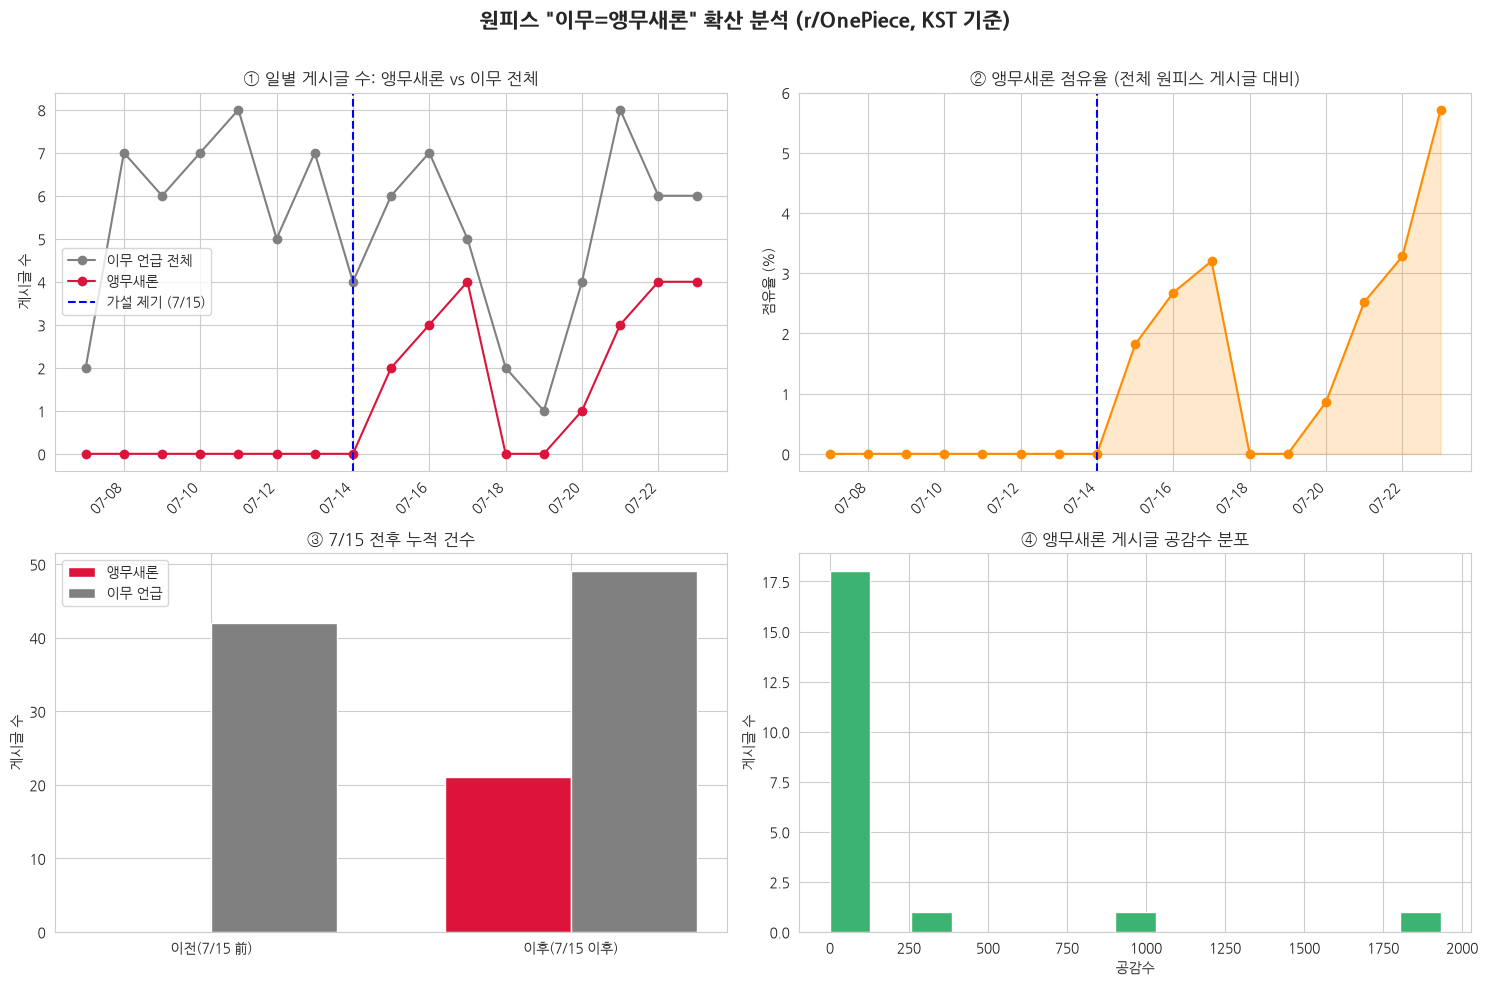

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. 시각화 (2x2 대시보드)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('원피스 "이무=앵무새론" 확산 분석 (r/OnePiece, KST 기준)',
             fontsize=15, fontweight='bold')

# (1) 일별 건수 시계열: 앵무새론 vs 이무 전체 ─────────────────────
ax = axes[0, 0]
ax.plot(daily['날짜'], daily['이무언급'], marker='o', label='이무 언급 전체', color='gray')
ax.plot(daily['날짜'], daily['앵무새론'], marker='o', label='앵무새론', color='crimson')
ax.axvline(CUTOFF, color='blue', linestyle='--', label='가설 제기 (7/15)')
ax.set_title('① 일별 게시글 수: 앵무새론 vs 이무 전체')
ax.set_ylabel('게시글 수'); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# (2) 점유율 추이 (분모②: 전체 원피스 게시글) ──────────────────
ax = axes[0, 1]
ax.plot(daily['날짜'], daily['점유율'], marker='o', color='darkorange')
ax.axvline(CUTOFF, color='blue', linestyle='--')
ax.fill_between(daily['날짜'], daily['점유율'], alpha=0.2, color='darkorange')
ax.set_title('② 앵무새론 점유율 (전체 원피스 게시글 대비)')
ax.set_ylabel('점유율 (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# (3) before/after 누적 막대 ──────────────────────────────────
ax = axes[1, 0]
grp = ['이전(7/15 前)', '이후(7/15 이후)']
vals_p = [b_parrot, a_parrot]
vals_i = [int(df.loc[before_mask, '이무언급'].sum()),
          int(df.loc[after_mask,  '이무언급'].sum())]
x = np.arange(2); w = 0.35
ax.bar(x - w/2, vals_p, w, label='앵무새론', color='crimson')
ax.bar(x + w/2, vals_i, w, label='이무 언급', color='gray')
ax.set_xticks(x); ax.set_xticklabels(grp)
ax.set_title('③ 7/15 전후 누적 건수'); ax.set_ylabel('게시글 수'); ax.legend()

# (4) 앵무새론 게시글 공감수 분포 ─────────────────────────────
ax = axes[1, 1]
ax.hist(df.loc[df['앵무새론'], '공감수'], bins=15,
        color='mediumseagreen', edgecolor='white')
ax.set_title('④ 앵무새론 게시글 공감수 분포')
ax.set_xlabel('공감수'); ax.set_ylabel('게시글 수')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

=== 주제별 점유율 (전체 2431 건) ===
         건수  점유율(%)
주제                 
기타     1883    77.5
만화/스포   164     6.7
이론/떡밥   145     6.0
팬아트      90     3.7
애니       69     2.8
코스프레     59     2.4
앵무새론     21     0.9

[저장] topic_share_bar.png


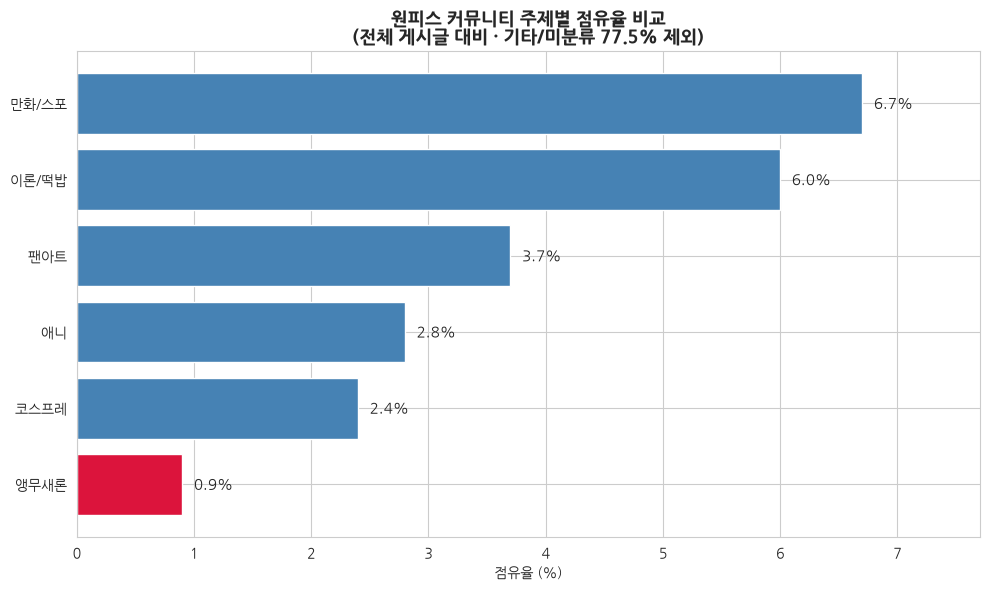

In [11]:
# -*- coding: utf-8 -*-
"""
================================================================================
 원피스 커뮤니티 주제별 점유율 비교 (막대그래프)
================================================================================
 목적:
   r/OnePiece 게시글을 '콘텐츠 종류'별 주제로 분류하고, 각 주제가 전체에서
   차지하는 점유율(share)을 가로 막대그래프로 비교한다.

 분류 방식 — '배타적 배정(mutually exclusive)':
   한 게시글은 오직 하나의 주제에만 속한다. 그래야 점유율 합이 100%가 되어
   '점유(share)'라는 표현이 정당해진다.
   구체적인 주제부터 먼저 채우고(우선순위), 어디에도 안 걸리면 '기타'로 보낸다.

 왜 가로 막대인가:
   - 크기 비교엔 막대 '길이'가 가장 정확한 시각 부호다(각도·면적보다 우수).
   - 라벨이 한글 텍스트라 가로로 눕히면 안 기울어지고, 정렬하면 순위가 한눈에 보인다.
   - (주의) 시간 변화가 아니라 '기간 누적 스냅샷' 비교이므로 막대가 적절하다.
================================================================================
"""
# ─────────────────────────────────────────────────────────────────────────────
# 2. 주제 배타적 배정 (우선순위: 위에 있는 규칙이 먼저 차지)
# ─────────────────────────────────────────────────────────────────────────────

def has(pattern):
    """제목에 정규식 pattern이 있으면 True인 불리언 Series 반환(결측 안전)."""
    return title.str.contains(pattern, case=False, na=False, regex=True)
 

imu, bird = has('imu'), has('bird')

# 규칙 목록: (주제명, 해당 조건). 구체적/특이한 주제를 위쪽에 둔다.
rules = [
    ('앵무새론',   has('parrot') | (imu & bird)),                 # 특정 팬이론(특이 단어)
    ('코스프레',   has('cosplay|cosplayer')),
    ('팬아트',     has('fanart|fan art|drew|drawing|sketch|art of|my art')),
    ('이론/떡밥',  has('theory|what if|foreshadow|hint|prediction|predict')),
    ('만화/스포',  has('manga|chapter|spoiler|raw scan|leak')),
    ('애니',       has('anime|episode')),
]

# 모두 '기타'로 초기화한 뒤, 아직 '기타'인 행에 한해 규칙을 순서대로 적용.
# → 이미 배정된 글은 다시 안 바뀌므로 '한 글=한 주제'가 보장된다.
df['주제'] = '기타'
for name, mask in rules:
    df.loc[(df['주제'] == '기타') & mask, '주제'] = name

# 주제별 건수와 점유율(전체 대비) 계산
counts = df['주제'].value_counts()
share = (counts / len(df) * 100).round(1)      # 퍼센트, 소수 1자리

summary = pd.DataFrame({'건수': counts, '점유율(%)': share})
print('=== 주제별 점유율 (전체', len(df), '건) ===')
print(summary.to_string())


# ─────────────────────────────────────────────────────────────────────────────
# 3. 가로 막대그래프
# ─────────────────────────────────────────────────────────────────────────────
# '기타'(미분류)는 76.9%로 압도적이라 함께 그리면 다른 막대가 뭉개진다.
# 따라서 '식별된 주제들끼리' 비교하도록 기타를 제외하고, 제목에 그 사실을 명시한다.
plot_data = share.drop('기타').sort_values()   # 오름차순 정렬(가로 막대는 아래→위로 커짐)

# 앵무새론만 강조색(이전 분석과 연결), 나머지는 회색
colors = ['crimson' if idx == '앵무새론' else 'steelblue' for idx in plot_data.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_data.index, plot_data.values, color=colors)

# 각 막대 끝에 수치 라벨 표시
for bar, val in zip(bars, plot_data.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=11)

etc_share = share['기타']
ax.set_title(f'원피스 커뮤니티 주제별 점유율 비교\n(전체 게시글 대비 · 기타/미분류 {etc_share}% 제외)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('점유율 (%)')
ax.set_xlim(0, plot_data.max() * 1.15)         # 라벨 잘림 방지 여유
plt.tight_layout()
plt.savefig('topic_share_bar.png', dpi=130, bbox_inches='tight')
print('\n[저장] topic_share_bar.png')
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. 최종 결론 요약
# ─────────────────────────────────────────────────────────────────────────────
peak = daily.loc[daily['점유율'].idxmax()]
print('\n' + '=' * 60)
print(' 결론 요약')
print('=' * 60)
print(f' • 7/15 이전 앵무새론 {b_parrot}건 → 이후 {a_parrot}건')
print(f' • 기준 A(불연속성): {verdict}')
print(f' • 점유율 최고일: {peak["날짜"].date()} '
      f'(전체 {int(peak["전체"])}건 중 {int(peak["앵무새론"])}건 = {peak["점유율"]:.1f}%)')
print('=' * 60)


 결론 요약
 • 7/15 이전 앵무새론 0건 → 이후 21건
 • 기준 A(불연속성): 확정 (불연속적 급증 관측)
 • 점유율 최고일: 2026-07-24 (전체 70건 중 4건 = 5.7%)
